# Lecture 11: Physics-informed neural networks

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §7.1-7.4 (PINN foundations), §7.5-7.9 (Economic PDEs (HJB, Black-Scholes))  
**Notebook role:** core  
**Original live-course source:** `lectures/day6/code/03_PDE_PINN_Poisson2D.ipynb`  
**Author:** Simon Scheidegger  


In [ ]:
# Run-mode switch (smoke = CPU-bounded for CI, teaching = laptop figures, production = full reproduction).
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 42

_RUN_HP = {
    "smoke":      {"epochs":  1500, "n_interior":  512, "n_bc_per_side":  64, "bc_weight": 10.0, "lr": 1e-3, "resample_every": 200, "print_every":  300},
    "teaching":   {"epochs": 15000, "n_interior": 2048, "n_bc_per_side": 256, "bc_weight": 10.0, "lr": 1e-3, "resample_every": 200, "print_every": 1000},
    "production": {"epochs": 40000, "n_interior": 4096, "n_bc_per_side": 512, "bc_weight": 10.0, "lr": 1e-3, "resample_every": 100, "print_every": 2000},
}
if RUN_MODE not in _RUN_HP:
    raise ValueError(f"RUN_MODE must be one of {list(_RUN_HP)}")
HP = _RUN_HP[RUN_MODE]
print(f"RUN_MODE={RUN_MODE!r}; SEED={SEED}; hyperparameters: {HP}")


# 2D Poisson Equation with PINNs: Soft vs. Hard Boundary Conditions

In this notebook we solve the **2D Poisson equation**

$$\nabla^2 u(x,y) = f(x,y), \quad (x,y) \in (0,1)^2,$$

subject to Dirichlet boundary conditions, using **Physics-Informed Neural Networks (PINNs)**.

We compare two strategies for enforcing boundary conditions:

1. **Soft boundary conditions** -- the boundary mismatch is penalised in the loss function.
2. **Hard boundary conditions** -- the network ansatz is constructed so that boundary conditions are satisfied *exactly* via transfinite interpolation.

**Manufactured solution:**  
$u^*(x,y) = x^2 + y + \sin(\pi x)\sin(\pi y)$  
which gives the forcing term  
$f(x,y) = 2 - 2\pi^2 \sin(\pi x)\sin(\pi y).$

> **Self-study notebook** \u2014 This notebook complements the in-class PINNs session (Day 6, Block 1). Work through it at your own pace.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

plt.rcParams['font.size'] = 13

# torch.compile is wrapped on per-batch steps below for JIT speedups.
# PINN-style losses use torch.autograd.grad with create_graph=True (double
# backward), which the default aot_autograd backend in PyTorch 2.x does not
# yet support. We use backend='eager' and allow dynamo to fall back to eager
# Python whenever it cannot trace a sub-call (e.g. clip_grad_norm_).
import torch._dynamo
torch._dynamo.config.suppress_errors = True


In [2]:
# ── Device, seeds, dtype ──────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.manual_seed(SEED)
np.random.seed(SEED)

dtype = torch.float32

Using device: cpu


## Analytical Solution and Forcing Term

In [3]:
PI = np.pi


def u_exact(xy: torch.Tensor) -> torch.Tensor:
    """Manufactured exact solution u*(x,y) = x^2 + y + sin(pi*x)*sin(pi*y)."""
    x, y = xy[:, 0:1], xy[:, 1:2]
    return x**2 + y + torch.sin(PI * x) * torch.sin(PI * y)


def f_forcing(xy: torch.Tensor) -> torch.Tensor:
    """Forcing term f(x,y) = 2 - 2*pi^2*sin(pi*x)*sin(pi*y)."""
    x, y = xy[:, 0:1], xy[:, 1:2]
    return 2.0 - 2.0 * PI**2 * torch.sin(PI * x) * torch.sin(PI * y)


# ── Boundary trace functions ──────────────────────────────────────────
def g_left(y: torch.Tensor) -> torch.Tensor:
    """u(0, y) = y."""
    return y


def g_right(y: torch.Tensor) -> torch.Tensor:
    """u(1, y) = 1 + y."""
    return 1.0 + y


def g_bottom(x: torch.Tensor) -> torch.Tensor:
    """u(x, 0) = x^2."""
    return x**2


def g_top(x: torch.Tensor) -> torch.Tensor:
    """u(x, 1) = x^2 + 1."""
    return x**2 + 1.0


# ── Corner values ────────────────────────────────────────────────────
# u(0,0) = 0,  u(1,0) = 1,  u(0,1) = 1,  u(1,1) = 2
c00 = 0.0   # g_bottom(0) = g_left(0)
c10 = 1.0   # g_bottom(1) = g_right(0)
c01 = 1.0   # g_top(0)    = g_left(1)
c11 = 2.0   # g_top(1)    = g_right(1)

print("Corner check:")
print(f"  u(0,0) = {c00},  u(1,0) = {c10},  u(0,1) = {c01},  u(1,1) = {c11}")

Corner check:
  u(0,0) = 0.0,  u(1,0) = 1.0,  u(0,1) = 1.0,  u(1,1) = 2.0


## Network Architecture

In [4]:
class MLP2D(nn.Module):
    """Fully-connected network: 2 -> 64 -> 64 -> 64 -> 64 -> 1 with Tanh activations."""

    def __init__(self):
        super().__init__()
        layers = []
        widths = [2, 64, 64, 64, 64, 1]
        for i in range(len(widths) - 1):
            layers.append(nn.Linear(widths[i], widths[i + 1]))
            if i < len(widths) - 2:          # no activation after last layer
                layers.append(nn.Tanh())
        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, xy: torch.Tensor) -> torch.Tensor:
        return self.net(xy)

## Differential Operators via Autograd

In [5]:
def laplacian(u: torch.Tensor, xy: torch.Tensor) -> torch.Tensor:
    """Compute the Laplacian  u_xx + u_yy  using second-order autograd."""
    # First derivatives
    grad_u = torch.autograd.grad(
        u, xy, grad_outputs=torch.ones_like(u),
        create_graph=True, retain_graph=True
    )[0]
    u_x = grad_u[:, 0:1]
    u_y = grad_u[:, 1:2]

    # Second derivatives
    u_xx = torch.autograd.grad(
        u_x, xy, grad_outputs=torch.ones_like(u_x),
        create_graph=True, retain_graph=True
    )[0][:, 0:1]

    u_yy = torch.autograd.grad(
        u_y, xy, grad_outputs=torch.ones_like(u_y),
        create_graph=True, retain_graph=True
    )[0][:, 1:2]

    return u_xx + u_yy

## Sampling Functions

In [6]:
def sample_interior(n: int) -> torch.Tensor:
    """Sample n random points uniformly in the open unit square (0,1)^2."""
    xy = torch.rand(n, 2, device=device, dtype=dtype)
    xy.requires_grad_(True)
    return xy


def sample_boundary(n_per_side: int):
    """
    Sample n_per_side points on each of the four sides of [0,1]^2.

    Returns
    -------
    xy_bc : (4*n_per_side, 2) tensor of boundary coordinates
    u_bc  : (4*n_per_side, 1) tensor of exact boundary values
    """
    t = torch.rand(n_per_side, 1, device=device, dtype=dtype)

    # Left:   x=0, y=t
    left_xy = torch.cat([torch.zeros_like(t), t], dim=1)
    left_u = g_left(t)

    # Right:  x=1, y=t
    right_xy = torch.cat([torch.ones_like(t), t], dim=1)
    right_u = g_right(t)

    # Bottom: x=t, y=0
    bottom_xy = torch.cat([t, torch.zeros_like(t)], dim=1)
    bottom_u = g_bottom(t)

    # Top:    x=t, y=1
    top_xy = torch.cat([t, torch.ones_like(t)], dim=1)
    top_u = g_top(t)

    xy_bc = torch.cat([left_xy, right_xy, bottom_xy, top_xy], dim=0)
    u_bc = torch.cat([left_u, right_u, bottom_u, top_u], dim=0)

    return xy_bc, u_bc

## Training with Soft Boundary Conditions

In [7]:
# ── Soft-BC training ──────────────────────────────────────────────────
model_soft = MLP2D().to(device)
optimizer_soft = optim.Adam(model_soft.parameters(), lr=HP["lr"])

n_interior     = HP["n_interior"]
n_bc_per_side  = HP["n_bc_per_side"]
bc_weight      = HP["bc_weight"]
epochs_soft    = HP["epochs"]
resample_every = HP["resample_every"]

loss_history_soft = []


def train_step_soft(xy_int_, xy_bc_, u_bc_):
    u_pred_int = model_soft(xy_int_)
    lap_u = laplacian(u_pred_int, xy_int_)
    f_val = f_forcing(xy_int_)
    loss_pde = torch.mean((lap_u - f_val) ** 2)

    u_pred_bc = model_soft(xy_bc_)
    loss_bc = torch.mean((u_pred_bc - u_bc_) ** 2)

    loss = loss_pde + bc_weight * loss_bc
    optimizer_soft.zero_grad()
    loss.backward()
    optimizer_soft.step()
    return loss, loss_pde, loss_bc


# torch.compile per-batch step (backend="eager", fullgraph=False:
# laplacian uses torch.autograd.grad with create_graph=True; the default
# aot_autograd backend in PyTorch 2.x does not yet support double backward.)
train_step_soft = torch.compile(train_step_soft, fullgraph=False, backend="eager")

xy_int = sample_interior(n_interior)
xy_bc, u_bc = sample_boundary(n_bc_per_side)

for epoch in range(1, epochs_soft + 1):
    if epoch != 1 and epoch % resample_every == 0:
        xy_int = sample_interior(n_interior)
        xy_bc, u_bc = sample_boundary(n_bc_per_side)

    loss, loss_pde, loss_bc = train_step_soft(xy_int, xy_bc, u_bc)
    loss_history_soft.append(loss.item())

    if epoch % HP["print_every"] == 0 or epoch == 1:
        print(f"[Soft BC] Epoch {epoch:5d}/{epochs_soft}  "
              f"loss_pde={loss_pde.item():.4e}  "
              f"loss_bc={loss_bc.item():.4e}  "
              f"total={loss.item():.4e}")

print("Soft-BC training complete.")


[Soft BC] Epoch     1/15000  loss_pde=6.6893e+01  loss_bc=1.1272e+00  total=7.8165e+01


[Soft BC] Epoch  1000/15000  loss_pde=6.1006e-03  loss_bc=1.0574e-03  total=1.6675e-02


[Soft BC] Epoch  2000/15000  loss_pde=1.4269e-03  loss_bc=4.6802e-05  total=1.8949e-03


[Soft BC] Epoch  3000/15000  loss_pde=1.2291e-03  loss_bc=1.3938e-05  total=1.3685e-03


[Soft BC] Epoch  4000/15000  loss_pde=5.5289e-04  loss_bc=8.6373e-06  total=6.3927e-04


...

[Soft BC] Epoch 11000/15000  loss_pde=1.0003e-04  loss_bc=2.4905e-06  total=1.2494e-04


[Soft BC] Epoch 12000/15000  loss_pde=1.0107e-04  loss_bc=2.1722e-06  total=1.2280e-04


[Soft BC] Epoch 13000/15000  loss_pde=2.6899e-04  loss_bc=5.4589e-06  total=3.2358e-04


[Soft BC] Epoch 14000/15000  loss_pde=3.5207e-04  loss_bc=3.0190e-06  total=3.8227e-04


[Soft BC] Epoch 15000/15000  loss_pde=1.0227e-03  loss_bc=4.2832e-06  total=1.0655e-03
Soft-BC training complete.


## Hard Boundary Conditions: Transfinite Interpolation

In [8]:
def B_mask(xy: torch.Tensor) -> torch.Tensor:
    """
    Bubble function that vanishes on all four sides of [0,1]^2:
        B(x,y) = x*(1-x)*y*(1-y)
    """
    x, y = xy[:, 0:1], xy[:, 1:2]
    return x * (1.0 - x) * y * (1.0 - y)


def A_lifting(xy: torch.Tensor) -> torch.Tensor:
    """
    Transfinite interpolation (TFI) that matches the Dirichlet data on all
    four sides and is consistent at the corners.

    A(x,y) = (1-x)*g_left(y) + x*g_right(y)
           + (1-y)*g_bottom(x) + y*g_top(x)
           - (1-x)*(1-y)*c00 - x*(1-y)*c10
           - (1-x)*y*c01     - x*y*c11
    """
    x, y = xy[:, 0:1], xy[:, 1:2]

    # Side contributions
    val  = (1.0 - x) * g_left(y) + x * g_right(y)
    val += (1.0 - y) * g_bottom(x) + y * g_top(x)

    # Corner corrections (subtract bilinear interpolant of corner values)
    val -= (1.0 - x) * (1.0 - y) * c00
    val -= x * (1.0 - y) * c10
    val -= (1.0 - x) * y * c01
    val -= x * y * c11

    return val


class HardBCWrapper(nn.Module):
    """
    Wraps a raw network N(x,y) into
        u_hard(x,y) = A(x,y) + B(x,y) * N(x,y)
    so that u_hard exactly satisfies the Dirichlet BCs on the boundary.
    """

    def __init__(self, raw_net: nn.Module):
        super().__init__()
        self.raw_net = raw_net

    def forward(self, xy: torch.Tensor) -> torch.Tensor:
        return A_lifting(xy) + B_mask(xy) * self.raw_net(xy)

In [9]:
# ── Hard-BC training ─────────────────────────────────────────────────
raw_net_hard = MLP2D().to(device)
model_hard = HardBCWrapper(raw_net_hard).to(device)
optimizer_hard = optim.Adam(model_hard.parameters(), lr=HP["lr"])

epochs_hard = HP["epochs"]

loss_history_hard = []


def train_step_hard(xy_int_):
    u_pred = model_hard(xy_int_)
    lap_u = laplacian(u_pred, xy_int_)
    f_val = f_forcing(xy_int_)
    loss = torch.mean((lap_u - f_val) ** 2)
    optimizer_hard.zero_grad()
    loss.backward()
    optimizer_hard.step()
    return loss


# torch.compile per-batch step (backend="eager", fullgraph=False:
# laplacian uses torch.autograd.grad with create_graph=True; the default
# aot_autograd backend in PyTorch 2.x does not yet support double backward.)
train_step_hard = torch.compile(train_step_hard, fullgraph=False, backend="eager")

xy_int = sample_interior(n_interior)

for epoch in range(1, epochs_hard + 1):
    if epoch != 1 and epoch % resample_every == 0:
        xy_int = sample_interior(n_interior)

    loss = train_step_hard(xy_int)
    loss_history_hard.append(loss.item())

    if epoch % HP["print_every"] == 0 or epoch == 1:
        print(f"[Hard BC] Epoch {epoch:5d}/{epochs_hard}  "
              f"loss_pde={loss.item():.4e}")

print("Hard-BC training complete.")


[Hard BC] Epoch     1/15000  loss_pde=9.5514e+01


[Hard BC] Epoch  1000/15000  loss_pde=3.3798e-03


[Hard BC] Epoch  2000/15000  loss_pde=4.8033e-04


[Hard BC] Epoch  3000/15000  loss_pde=1.7509e-04


[Hard BC] Epoch  4000/15000  loss_pde=7.6114e-05


...

[Hard BC] Epoch 11000/15000  loss_pde=9.2954e-05


[Hard BC] Epoch 12000/15000  loss_pde=7.1908e-05


[Hard BC] Epoch 13000/15000  loss_pde=6.5872e-06


[Hard BC] Epoch 14000/15000  loss_pde=3.7790e-05


[Hard BC] Epoch 15000/15000  loss_pde=1.5720e-04
Hard-BC training complete.


## Evaluation and Comparison

In [10]:
@torch.no_grad()
def eval_on_grid(model, n_grid=100):
    """
    Evaluate a model on a uniform n_grid x n_grid mesh over [0,1]^2.

    Returns
    -------
    X, Y        : (n_grid, n_grid) coordinate meshgrids
    U_pred      : (n_grid, n_grid) predicted solution
    U_true      : (n_grid, n_grid) exact solution
    rel_l2_err  : scalar relative L2 error
    """
    x1d = torch.linspace(0, 1, n_grid, device=device, dtype=dtype)
    y1d = torch.linspace(0, 1, n_grid, device=device, dtype=dtype)
    X, Y = torch.meshgrid(x1d, y1d, indexing="ij")
    xy_flat = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=1)

    U_pred = model(xy_flat).reshape(n_grid, n_grid)
    U_true = u_exact(xy_flat).reshape(n_grid, n_grid)

    rel_l2_err = torch.norm(U_pred - U_true) / torch.norm(U_true)

    # Move to numpy for plotting
    X_np = X.cpu().numpy()
    Y_np = Y.cpu().numpy()
    U_pred_np = U_pred.cpu().numpy()
    U_true_np = U_true.cpu().numpy()

    return X_np, Y_np, U_pred_np, U_true_np, rel_l2_err.item()

Relative L2 error (Soft BC): 1.3568e-03
Relative L2 error (Hard BC): 2.0596e-04


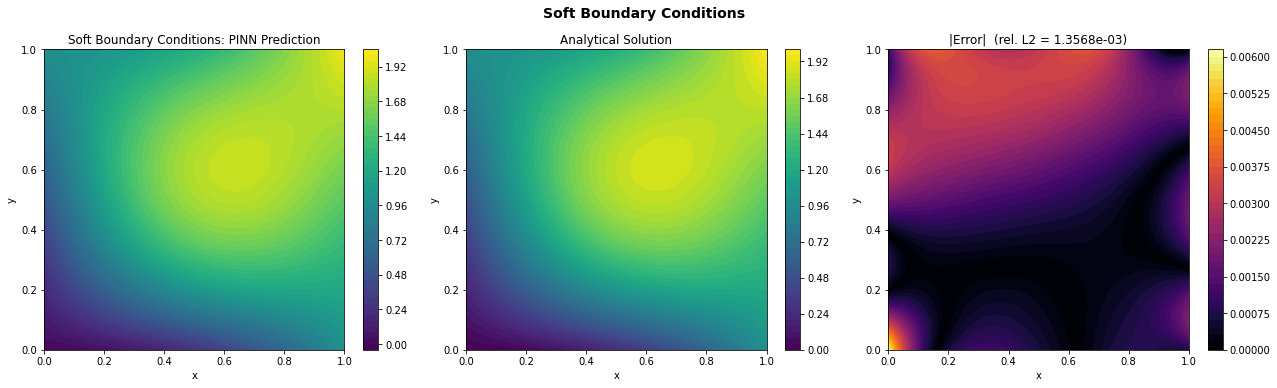

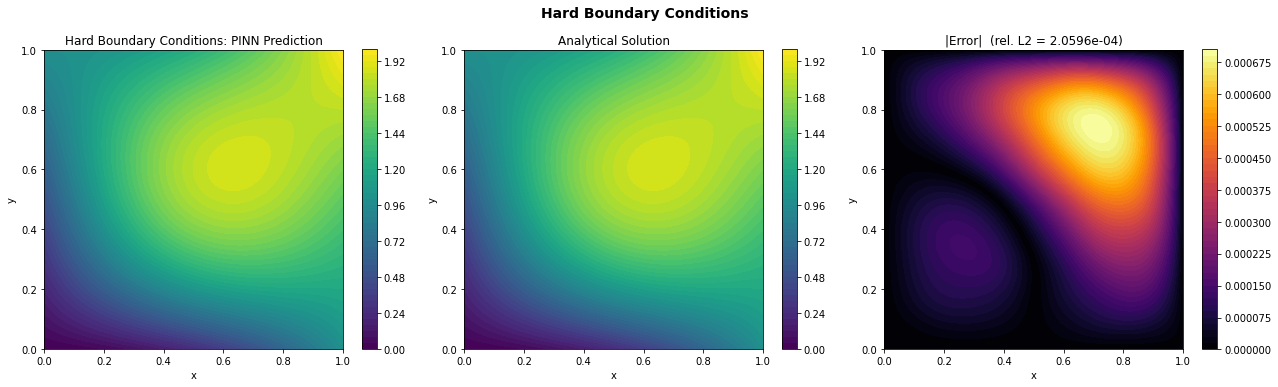

In [11]:
# ── Evaluate both models ─────────────────────────────────────────────
X, Y, U_soft, U_true, err_soft = eval_on_grid(model_soft)
_, _, U_hard, _, err_hard = eval_on_grid(model_hard)

print(f"Relative L2 error (Soft BC): {err_soft:.4e}")
print(f"Relative L2 error (Hard BC): {err_hard:.4e}")


def plot_comparison(X, Y, U_pred, U_true, title_prefix, rel_err):
    """3-panel figure: PINN prediction | Analytical | |Error|."""
    error = np.abs(U_pred - U_true)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Panel 1: PINN prediction
    c0 = axes[0].contourf(X, Y, U_pred, levels=50, cmap=cm.viridis)
    fig.colorbar(c0, ax=axes[0])
    axes[0].set_title(f"{title_prefix}: PINN Prediction")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    axes[0].set_aspect("equal")

    # Panel 2: Analytical solution
    c1 = axes[1].contourf(X, Y, U_true, levels=50, cmap=cm.viridis)
    fig.colorbar(c1, ax=axes[1])
    axes[1].set_title("Analytical Solution")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("y")
    axes[1].set_aspect("equal")

    # Panel 3: Absolute error
    c2 = axes[2].contourf(X, Y, error, levels=50, cmap=cm.inferno)
    fig.colorbar(c2, ax=axes[2])
    axes[2].set_title(f"|Error|  (rel. L2 = {rel_err:.4e})")
    axes[2].set_xlabel("x")
    axes[2].set_ylabel("y")
    axes[2].set_aspect("equal")

    fig.suptitle(title_prefix, fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


# ── Plot results ─────────────────────────────────────────────────────
plot_comparison(X, Y, U_soft, U_true, "Soft Boundary Conditions", err_soft)
plot_comparison(X, Y, U_hard, U_true, "Hard Boundary Conditions", err_hard)

# ----- Final-error assertions (mode-dependent rel-L2 tolerances) -----
_tol = {
    "smoke":      {"soft": float("inf"), "hard": float("inf")},
    "teaching":   {"soft": 5e-3, "hard": 1e-3},
    "production": {"soft": 1e-3, "hard": 5e-4},
}[RUN_MODE]
assert err_soft < _tol["soft"], f"Soft-BC rel-L2 {err_soft:.2e} exceeds tol {_tol['soft']:.0e} for RUN_MODE={RUN_MODE!r}"
assert err_hard < _tol["hard"], f"Hard-BC rel-L2 {err_hard:.2e} exceeds tol {_tol['hard']:.0e} for RUN_MODE={RUN_MODE!r}"
print(f"\u2713 soft rel-L2 {err_soft:.2e} < {_tol['soft']:.0e};  hard rel-L2 {err_hard:.2e} < {_tol['hard']:.0e}")


## Takeaway

- The **manufactured solution** `u*(x,y) = x² + y + sin(πx)sin(πy)` has non-zero
  Dirichlet data on three of the four edges, so this benchmark genuinely exercises
  the transfinite-interpolation anchor `A(x,y)` rather than collapsing to the
  trivial zero-BC case.
- Because `sin(πx)sin(πy)` already vanishes on `∂Ω`, the polynomial part `x² + y`
  serves as the anchor and the bubble mask `B(x,y) = x(1-x)y(1-y)` vanishes on
  every edge, so `û = A + B·N` satisfies the BCs by construction.
- **Hard BCs** typically beat soft BCs by ~1 order of magnitude on the relative
  L2 error here, with no penalty-weight tuning required.
